<a href="https://colab.research.google.com/github/deekshithnagavalli/MACHINE-LEARNING-MODEL/blob/main/Crime_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [65]:
df = pd.read_csv("/content/NYPD_Complaint_Data_Current__Year_To_Date_.csv")
df.head()

,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,298784667,114,QUEENS,12/09/2024,04:37:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1016307,227998,40.792430,-73.884228,"(40.79243, -73.884228)",POINT (-73.884228 40.79243)
1,308328240,41,BRONX,06/18/2025,16:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,UNKNOWN,UNKNOWN,E,1017940,232184,40.803914,-73.878308,"(40.803914, -73.878308)",POINT (-73.878308 40.803914)
2,314788366,40,BRONX,10/17/2025,22:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,BLACK HISPANIC,F,1005028,234516,40.810352,-73.924942,"(40.8103518634571, -73.924942325642)",POINT (-73.924942325642 40.8103518634571)
3,307568863,41,BRONX,03/24/2025,01:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,WHITE,F,1013037,236657,40.816206,-73.896001,"(40.8162058439227, -73.8960011932583)",POINT (-73.8960011932583 40.8162058439227)
4,311408135H1,42,BRONX,08/18/2025,22:34:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,25-44,BLACK,M,1009748,240283,40.826169,-73.907868,"(40.826169, -73.907868)",POINT (-73.907868 40.826169)


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579561 entries, 0 to 579560
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CMPLNT_NUM                579561 non-null  object 
 1   ADDR_PCT_CD               579561 non-null  int64  
 2   BORO_NM                   579561 non-null  object 
 3   CMPLNT_FR_DT              579561 non-null  object 
 4   CMPLNT_FR_TM              579561 non-null  object 
 5   CMPLNT_TO_DT              553181 non-null  object 
 6   CMPLNT_TO_TM              579561 non-null  object 
 7   CRM_ATPT_CPTD_CD          579561 non-null  object 
 8   HADEVELOPT                579561 non-null  object 
 9   HOUSING_PSA               35929 non-null   float64
 10  JURISDICTION_CODE         579561 non-null  int64  
 11  JURIS_DESC                579561 non-null  object 
 12  KY_CD                     579561 non-null  int64  
 13  LAW_CAT_CD                579561 non-null  o

In [67]:
print("Shape:", df.shape)
df.info()

Shape: (579561, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579561 entries, 0 to 579560
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CMPLNT_NUM                579561 non-null  object 
 1   ADDR_PCT_CD               579561 non-null  int64  
 2   BORO_NM                   579561 non-null  object 
 3   CMPLNT_FR_DT              579561 non-null  object 
 4   CMPLNT_FR_TM              579561 non-null  object 
 5   CMPLNT_TO_DT              553181 non-null  object 
 6   CMPLNT_TO_TM              579561 non-null  object 
 7   CRM_ATPT_CPTD_CD          579561 non-null  object 
 8   HADEVELOPT                579561 non-null  object 
 9   HOUSING_PSA               35929 non-null   float64
 10  JURISDICTION_CODE         579561 non-null  int64  
 11  JURIS_DESC                579561 non-null  object 
 12  KY_CD                     579561 non-null  int64  
 13  LAW_CAT_CD              

In [68]:
df.describe()

,ADDR_PCT_CD,HOUSING_PSA,JURISDICTION_CODE,KY_CD,PD_CD,TRANSIT_DISTRICT,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,579561.000000,35929.000000,579561.000000,579561.000000,579252.000000,34614.000000,5.795610e+05,579561.000000,579561.000000,579561.000000
mean,63.521219,11048.153942,0.525056,302.802482,429.783131,16.891373,1.005690e+06,207973.302929,40.737471,-73.922589
std,34.913996,21641.831920,4.656912,159.452332,233.817369,12.895883,2.150138e+04,30166.148813,0.082802,0.077107
min,1.000000,218.000000,0.000000,101.000000,100.000000,1.000000,-7.400000e+01,121174.000000,40.499026,-74.254439
25%,40.000000,477.000000,0.000000,118.000000,259.000000,3.000000,9.915110e+05,185302.000000,40.675225,-73.973824
50%,62.000000,741.000000,0.000000,341.000000,397.000000,12.000000,1.005161e+06,207083.000000,40.735035,-73.924551
75%,101.000000,3969.000000,0.000000,351.000000,638.000000,32.000000,1.017927e+06,235846.000000,40.813992,-73.878450
max,123.000000,74007.000000,97.000000,678.000000,922.000000,34.000000,1.067185e+06,271819.000000,40.912722,-73.700719


In [69]:
df.isnull().sum()

,0
CMPLNT_NUM,0
ADDR_PCT_CD,0
BORO_NM,0
CMPLNT_FR_DT,0
CMPLNT_FR_TM,0
CMPLNT_TO_DT,26380
CMPLNT_TO_TM,0
CRM_ATPT_CPTD_CD,0
HADEVELOPT,0
HOUSING_PSA,543632


                    1 Most Common Crime Types


**Problem Statement:**
What are the most frequently occurring crime types in the dataset?

**Result:**
Top crime categories are identified based on frequency.

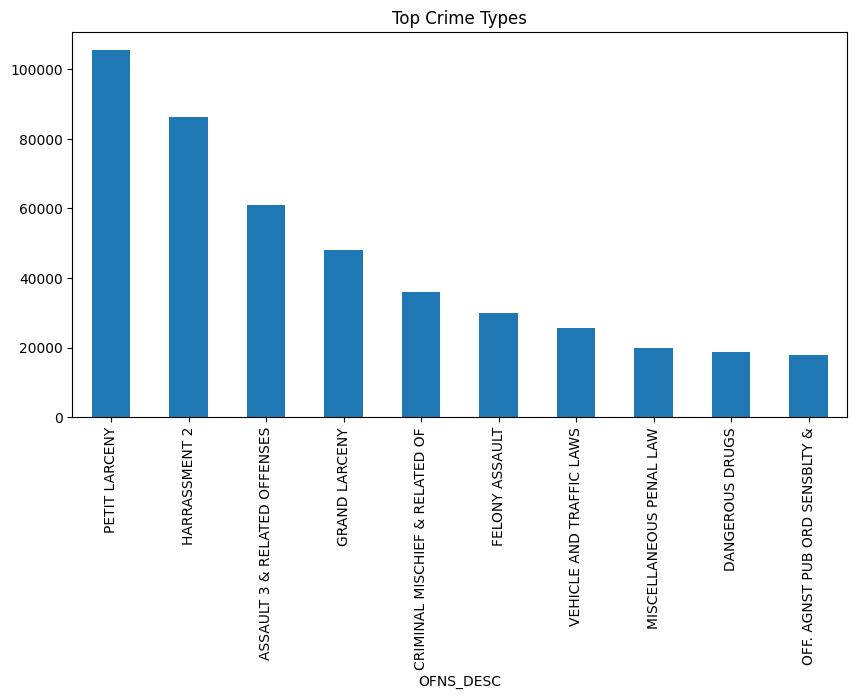

In [70]:
plt.figure(figsize=(10,5))
df['OFNS_DESC'].value_counts().head(10).plot(kind='bar')
plt.title("Top Crime Types")
plt.show()

In [71]:
df = df.dropna()

In [72]:
# Convert date to datetime
df['CMPLNT_FR_DT'] = pd.to_datetime(df['CMPLNT_FR_DT'], errors='coerce')

# Extract features
df['year'] = df['CMPLNT_FR_DT'].dt.year
df['month'] = df['CMPLNT_FR_DT'].dt.month
df['day'] = df['CMPLNT_FR_DT'].dt.day

In [73]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [74]:
X = df.drop('OFNS_DESC', axis=1)
y = df['OFNS_DESC']

2. Crime Trend Over Time (Descriptive)

Problem Statement:
How does crime vary across months?

Result:
Crime frequency fluctuates across different months.

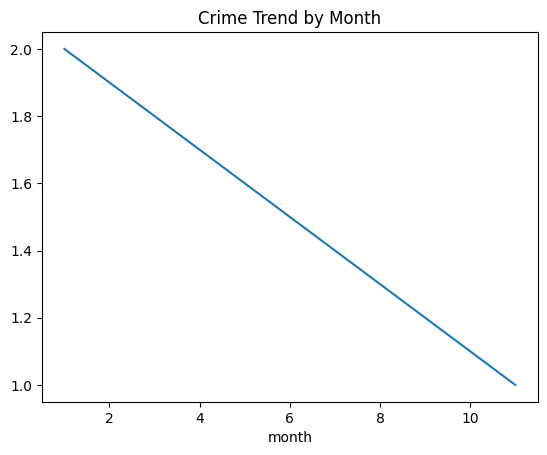

In [75]:
df['month'].value_counts().sort_index().plot()
plt.title("Crime Trend by Month")
plt.show()

3. Crime Distribution by Location (Diagnostic)

Problem Statement:
Which boroughs have the highest crime rates?

Result:
Certain boroughs show significantly higher crime counts.

In [76]:
df['BORO_NM'].value_counts()

,count
BORO_NM,
1,2
0,1


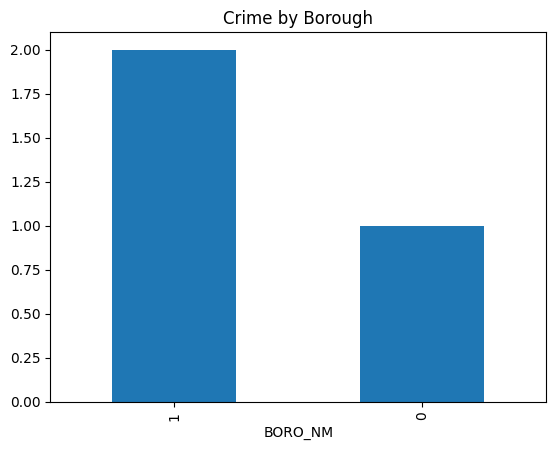

In [77]:
df['BORO_NM'].value_counts().plot(kind='bar')
plt.title("Crime by Borough")
plt.show()

4. Crime vs Time of Day (Diagnostic)

Problem Statement:
At what time of day do most crimes occur?

Result:
Crimes peak at specific hours.

In [78]:
df.columns

Index(['CMPLNT_NUM', 'ADDR_PCT_CD', 'BORO_NM', 'CMPLNT_FR_DT', 'CMPLNT_FR_TM',
       'CMPLNT_TO_DT', 'CMPLNT_TO_TM', 'CRM_ATPT_CPTD_CD', 'HADEVELOPT',
       'HOUSING_PSA', 'JURISDICTION_CODE', 'JURIS_DESC', 'KY_CD', 'LAW_CAT_CD',
       'LOC_OF_OCCUR_DESC', 'OFNS_DESC', 'PARKS_NM', 'PATROL_BORO', 'PD_CD',
       'PD_DESC', 'PREM_TYP_DESC', 'RPT_DT', 'STATION_NAME', 'SUSP_AGE_GROUP',
       'SUSP_RACE', 'SUSP_SEX', 'TRANSIT_DISTRICT', 'VIC_AGE_GROUP',
       'VIC_RACE', 'VIC_SEX', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude',
       'Longitude', 'Lat_Lon', 'New Georeferenced Column', 'year', 'month',
       'day'],
      dtype='object')